--- One-Class SVM (OCSVM) ---
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.
Antrenare OCSVM în curs pe 345659 rânduri...

RAPORT FINAL:
 SISTEM AUDIT SSH - REZULTATE OCSVM 
Scor AUC: 0.4647
Timp Antrenare: 397.77s
              precision    recall  f1-score   support

      Normal       0.67      0.16      0.26     86415
    Anomalie       0.09      0.50      0.15     13835

    accuracy                           0.21    100250
   macro avg       0.38      0.33      0.20    100250
weighted avg       0.59      0.21      0.24    100250



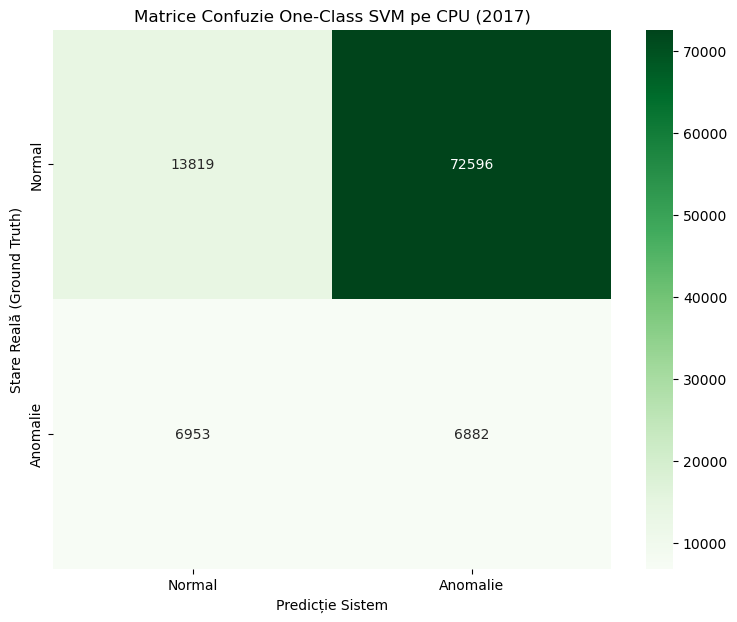

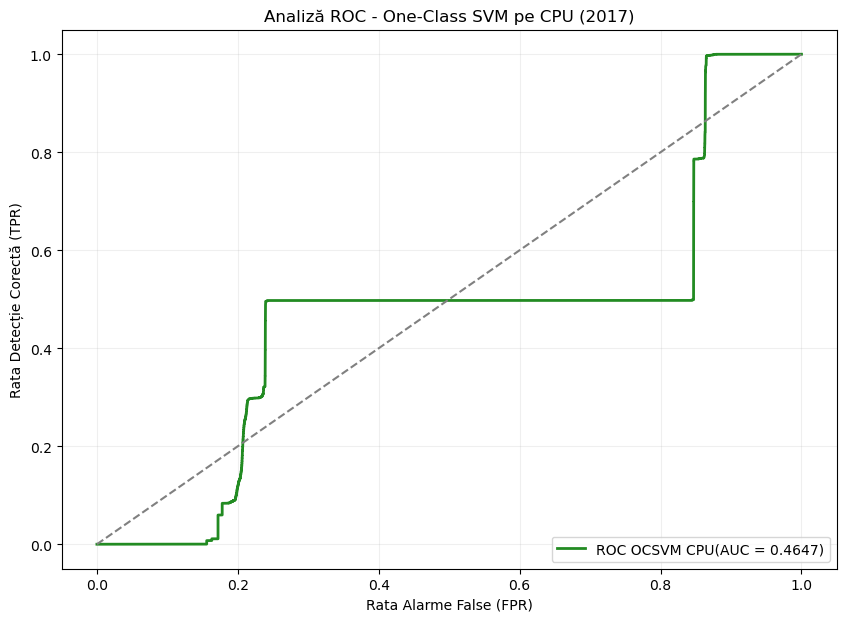

In [1]:
import torch
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler



prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\One_class_SVM'
rezultate_path = r'D:\disertatie\rezultate_2017\One_class_SVM'


for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)


print("--- One-Class SVM (OCSVM) ---")

X_train = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt')).numpy()
X_test = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt')).numpy()
y_test = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt')).numpy()
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test.shape[0]} rânduri.")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ocsvm = OneClassSVM(
    kernel='linear',
    gamma='scale',
    nu=0.03,
    cache_size=12000
)

start_time = time.time()
print(f"Antrenare OCSVM în curs pe {len(X_train)} rânduri...")
ocsvm.fit(X_train)
train_time = time.time() - start_time


joblib.dump(ocsvm, os.path.join(model_save_path, 'model_ocsvm_cpu.pkl'))

decision_scores = ocsvm.decision_function(X_test)
y_scores = -decision_scores

y_pred = [1 if x == -1 else 0 for x in ocsvm.predict(X_test)]

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
full_text = f"SISTEM AUDIT SSH - REZULTATE OCSVM \n"
full_text += f"Scor AUC: {roc_auc:.4f}\n"
full_text += f"Timp Antrenare: {train_time:.2f}s\n"
full_text += "="*50 + "\n"
full_text += report


print("\nRAPORT FINAL:\n", full_text)
with open(os.path.join(rezultate_path, 'raport_final_ocsvm_cpu.txt'), 'w') as f:
    f.write(full_text)


plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice Confuzie One-Class SVM pe CPU (2017)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ocsvm_cpu.png'), dpi=300)


plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC OCSVM CPU(AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Analiză ROC - One-Class SVM pe CPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ocsvm_cpu.png'), dpi=300)

plt.show() 